In [ ]:
!pip install kaggle -q

In [ ]:
import os

os.environ['KAGGLE_USERNAME'] = "abhinavsingh092007"
os.environ['KAGGLE_KEY'] = "KGAT_a4b5adc53cf077ab4b87f330f168df72"

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ahmedhamada0/brain-tumor-detection")

print("Path to dataset files:", path)

In [ ]:
!kaggle datasets download -d ahmedhamada0/brain-tumor-detection
!unzip -q brain-tumor-detection.zip -d brain_tumor_data
!ls brain_tumor_data/

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import random

base_dir = "brain_tumor_data"

for root,dirs,files in os.walk(base_dir):
  level = root.replace(base_dir,'').count(os.sep)
  indent = ' ' * 2 * level
  print(f"{indent}{os.path.basename(root)}/")
  if level < 2:
    subindent = ' '* 2*(level + 1)
    print(f'{subindent}{len(files)} files')
  if level > 1:
    break

In [ ]:
import glob
yes_dir = glob.glob(base_dir + '/**/yes' , recursive = True)[0]
no_dir = glob.glob(base_dir + '/**/no' , recursive = True)[0]

yes_images = os.listdir(yes_dir)
no_images = os.listdir(no_dir)

print(f"Tumor (yes):{len(yes_images)} images")
print(f"NO tumor (No): {len(no_images)} images")

fig , axes =plt.subplots(2,4,figsize=(14,7))

for i, ax in enumerate(axes[0]):
  img=Image.open(os.path.join(yes_dir,random.choice(yes_images))).convert("RGB")
  ax.imshow(img); ax.set_title("tumor", color="red"); ax.axis("off")
for i,ax in enumerate(axes[1]):
  img=Image.open(os.path.join(no_dir,random.choice(no_images))).convert("RGB")
  ax.imshow(img); ax.set_title("No Tumor", color="red"); ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms,datasets,models
from torch.utils.data import DataLoader,random_split
import numpy as np

data_root = os.path.dirname(yes_dir)
print(f"Dataset root: {data_root}")

train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2 , contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456,0.406],[0.229,0.244,0.255])
])
val_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.244,0.255])
    ])
full_dataset = datasets.ImageFolder(root=data_root)
print(f'Classes: {full_dataset.classes}')
print(f"Total samples: {len(full_dataset)}")

n=len(full_dataset)
n_train = int(0.8*n)
n_val = int(0.1 * n)
n_test = n -n_train -n_val

train_set, val_set, test_set = random_split(
    full_dataset, [n_train,n_val,n_test],
    generator=torch.Generator().manual_seed(42)
)
train_set.dataset.transform = train_transforms
from torch.utils.data import Subset
class TransfromSubset(torch.utils.data.Dataset):
  def __init__(self,subset,transform):
    self.subset = subset
    self.transform = transforms

  def __len__(self): return len(self.subset)
  def __getitem__(self, idx):
    img, label = self.subset[idx]
    return img,label

train_ds = datasets.ImageFolder(root=data_root,transform=train_transforms)
val_ds = datasets.ImageFolder(root=data_root,transform=val_transforms)
test_ds = datasets.ImageFolder(root=data_root,transform=val_transforms)

indices = list(range(n))
torch.manual_seed
perm =torch.randperm(n).tolist()
train_idx= perm[:n_train]
val_idx = perm[n_train:n_train+n_val]
test_idx =perm[n_train+n_val:]

train_loader = DataLoader(Subset(train_ds,train_idx),batch_size=32,shuffle=True,num_workers=2)
val_loader   = DataLoader(Subset(val_ds,   val_idx),   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(Subset(test_ds,  test_idx),  batch_size=32, shuffle=False, num_workers=2)

print(f"Train: {len(train_idx)} | Val: {len(val_idx)} |Test: {len(test_idx)}")

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

In [ ]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for name,param in model.named_parameters():
  if 'layer4' not in name and 'fc' not in name: # corrected layer name
    param.requires_grad = False

num_features = model.fc.in_features
# Updated to 4 output classes to match the dataset
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_features, 4) # Corrected from 2 to 4
)
model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f'Trainable parameters: {trainable:,} / {total:,}')

In [ ]:
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

criterion = nn.CrossEntropyLoss()
optimizer =Adam(filter(lambda p: p.requires_grad,model.parameters()),lr=1e-4,weight_decay=1e-4)
schedular = ReduceLROnPlateau(optimizer,mode="min",patience=3,factor=0.5)
def train_epoch(model,loader,optimiizer,criterion):
  model.train()
  total_loss,correct,total = 0,0,0
  for imgs,labels in loader:
    imgs,labels = imgs.to(device),labels.to(device)
    optimizer.zero_grad()
    outputs=model(imgs)
    loss = criterion(outputs,labels)
    loss.backward()
    optimizer.step()
    total_loss += loss.item() * imgs.size(0)
    preds = outputs.argmax(dim=1)
    correct +=(preds == labels).sum().item()
    total += labels.size(0)
  return total_loss/total,correct/total
@torch.no_grad()
def eval_epoch(model,loader,criterion):
  model.eval()
  total_loss,correct,total= 0,0,0
  for imgs,labels in loader:
    imgs,labels = imgs.to(device),labels.to(device)
    outputs = model(imgs)
    loss = criterion(outputs,labels)
    total_loss += loss.item() * imgs.size(0)
    preds = outputs.argmax(dim=1)
    correct += (preds == labels).sum().item()
    total += labels.size(0)
  return total_loss/total,correct/total


In [12]:
NUM_EPOCHS =20
best_val_acc =0
history ={"train_loss" : [],"train_acc":[],"val_loss":[],"val_acc":[]}
for epoch in range(1,NUM_EPOCHS + 1):
  train_loss,train_acc=train_epoch(model,train_loader,optimizer,criterion)
  val_loss,val_acc = eval_epoch(model,val_loader,criterion)
  schedular.step(val_loss)


  history["train_loss"].append(train_loss)
  history["train_acc"].append(train_acc)
  history["val_loss"].append(val_loss)
  history["val_acc"].append(val_acc)


  print(f'Epoch {epoch:02d}/{NUM_EPOCHS} | '
        f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')

  if val_acc > best_val_acc:
    best_val_acc = val_acc
    torch.save({
        "epoch" : epoch,
        "model_state_dict" : model.state_dict(),
        "optimizer_state_dict" : optimizer.state_dict(),
        "val_acc" : best_val_acc,
        "history" : history
    },"best_model.pth")
    print(f"Best Model saved! Val Acc:{val_acc:.4f}")
print(f'\nBest Validation Accuracy: {best_val_acc:.4f}')

Epoch 01/20 | Train Loss: 0.3798 Acc: 0.7766 | Val Loss: 0.4754 Acc: 0.6995
Best Model saved! Val Acc:0.6995
Epoch 02/20 | Train Loss: 0.3660 Acc: 0.7940 | Val Loss: 0.4829 Acc: 0.7021
Best Model saved! Val Acc:0.7021
Epoch 03/20 | Train Loss: 0.3693 Acc: 0.7821 | Val Loss: 0.5043 Acc: 0.6891
Epoch 04/20 | Train Loss: 0.3725 Acc: 0.7778 | Val Loss: 0.4993 Acc: 0.6969
Epoch 05/20 | Train Loss: 0.3579 Acc: 0.7940 | Val Loss: 0.4943 Acc: 0.6943
Epoch 06/20 | Train Loss: 0.3658 Acc: 0.7817 | Val Loss: 0.4967 Acc: 0.6736
Epoch 07/20 | Train Loss: 0.3581 Acc: 0.7863 | Val Loss: 0.4969 Acc: 0.6632
Epoch 08/20 | Train Loss: 0.3505 Acc: 0.7960 | Val Loss: 0.5029 Acc: 0.6865
Epoch 09/20 | Train Loss: 0.3497 Acc: 0.7944 | Val Loss: 0.5084 Acc: 0.6684
Epoch 10/20 | Train Loss: 0.3471 Acc: 0.8002 | Val Loss: 0.5035 Acc: 0.6762
Epoch 11/20 | Train Loss: 0.3458 Acc: 0.7995 | Val Loss: 0.5094 Acc: 0.6943
Epoch 12/20 | Train Loss: 0.3476 Acc: 0.7927 | Val Loss: 0.5184 Acc: 0.6762
Epoch 13/20 | Train Lo

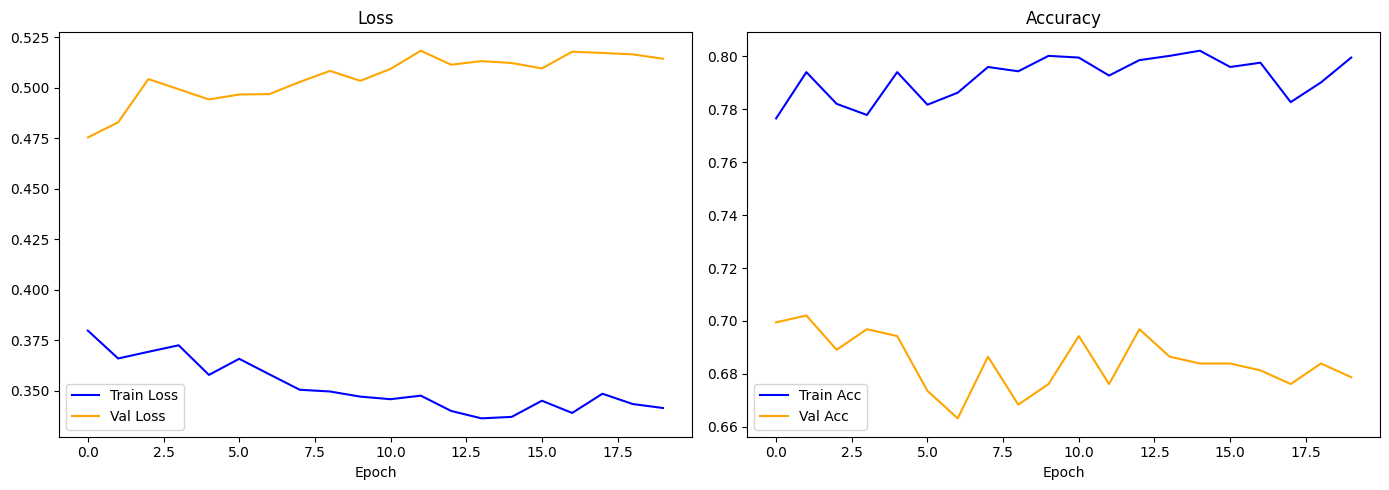

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_loss'], label='Train Loss', color='blue')
ax1.plot(history['val_loss'], label='Val Loss', color='orange')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend()

ax2.plot(history['train_acc'], label='Train Acc', color='blue')
ax2.plot(history['val_acc'], label='Val Acc', color='orange')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

                 precision    recall  f1-score   support

Br35H-Mask-RCNN       0.27      0.23      0.25        87
             no       0.99      0.99      0.99       157
           pred       0.50      0.33      0.40         3
            yes       0.55      0.61      0.58       140

       accuracy                           0.67       387
      macro avg       0.58      0.54      0.55       387
   weighted avg       0.66      0.67      0.67       387



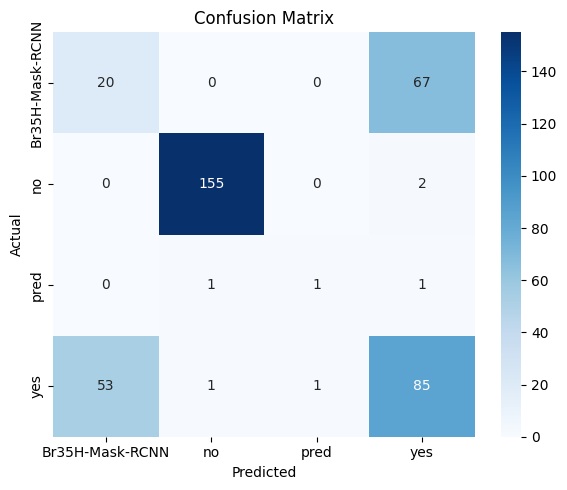

In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Load best model
checkpoint = torch.load('best_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

class_names = full_dataset.classes  # ['no', 'yes']
print(classification_report(all_labels, all_preds, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual'); ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [16]:
export_data = {
    'model_state_dict': model.state_dict(),
    'classes': full_dataset.classes,
    'architecture': 'resnet18',
    'input_size': 224,
    'val_accuracy': best_val_acc
}
torch.save(export_data, 'brain_tumor_model.pth')
print('✅ Model exported as brain_tumor_model.pth')

# Download the model
from google.colab import files
files.download('brain_tumor_model.pth')
print('Model downloaded! Use it with the FastAPI app.')

✅ Model exported as brain_tumor_model.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model downloaded! Use it with the FastAPI app.


Test image: brain_tumor_data/yes/y510.jpg
Prediction: yes (confidence: 71.57%)
Probabilities: {'Br35H-Mask-RCNN': 0.2732500433921814, 'no': 0.007011329755187035, 'pred': 0.0040770708583295345, 'yes': 0.7156615257263184}


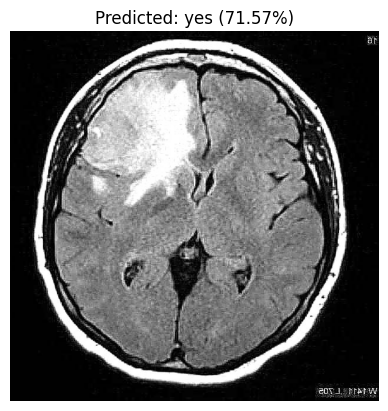

In [17]:
def predict_image(model, image_path, device):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    img = Image.open(image_path).convert('RGB')
    tensor = transform(img).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        outputs = model(tensor)
        probs = torch.softmax(outputs, dim=1)[0]
        pred_idx = probs.argmax().item()
    classes = full_dataset.classes
    return {
        'prediction': classes[pred_idx],
        'confidence': probs[pred_idx].item(),
        'probabilities': {c: probs[i].item() for i, c in enumerate(classes)}
    }

# Test on a random image
test_img = os.path.join(yes_dir, random.choice(yes_images))
result = predict_image(model, test_img, device)
print(f'Test image: {test_img}')
print(f'Prediction: {result["prediction"]} (confidence: {result["confidence"]:.2%})')
print(f'Probabilities: {result["probabilities"]}')

img = Image.open(test_img)
plt.imshow(img); plt.title(f'Predicted: {result["prediction"]} ({result["confidence"]:.2%})')
plt.axis('off'); plt.show()